# Emulating and calibrating a nuclear breakup reaction

This notebook is a complete Bayesian calibration of an expensive model for nuclear breakup reactions using BAND framework tools [`bfrescox`](https://github.com/bandframework/Bfrescox) and [`surmise`](https://github.com/bandframework/surmise). The goal is to reproduce the [**Sürer, Nunes, Plumlee & Wild, *Phys. Rev. C* 106, 024607 (2022)**.](https://journals.aps.org/prc/abstract/10.1103/PhysRevC.106.024607), by inferring the Asymptotic Normalization Coefficient (ANC) of the exotic $^8$B proton halo nucleus from measurements of its breakup. 

---

### The physics

$^{8}$B is a *proton halo* nucleus: a single proton bound to a $^{7}$Be core by only 137 keV. The proton is bound so loosely that it orbits far outside the core! If you shoot it at a $^{208}$Pb target at 80 MeV/nucleon the proton and the core will *breakup*:

$$^{8}\mathrm{B} + {}^{208}\mathrm{Pb} \;\longrightarrow\; {}^{7}\mathrm{Be} + p + {}^{208}\mathrm{Pb}$$

We model this with **continuum discretized coupled channels** (CDCC) in [FRESCOX](https://github.com/LLNL/Frescox), driven using BAND software [bfrescoxpro](https://bfrescox.readthedocs.io/en/latest/advanced_users.html). This a very computationally expensive simulation. The goal is learn from the double differential breakup cross section $d\sigma_{bu}/(d\Omega dE)$, the unknown parameters in the 2-body interactions between the constituent clusters in the reaction, e.g. $^{8}\mathrm{B} \leftrightarrow {}^{208}\mathrm{Pb}$, ${}^{7}\mathrm{Be} \leftrightarrow {}^{208}\mathrm{Pb}$, and ${}^{7}\mathrm{Be} \leftrightarrow p$. In particular, that $^{7}$Be–$p$ effective interaction is especially interesting: it tells us about what effective force the weakly bound halo proton in $^{8}\mathrm{B}$ feels, and therefore, its single particle structure. 

One interesting aspect of that structure is encoded in the Asymptotic Normalization Coefficient (ANC) of the overlap wavefunction $\langle ^{8}\mathrm{B} | ^{7}\mathrm{Be} + p\rangle$, which we will able to extract from the $^{7}$Be–$p$ potential. The ANC just tells us how much the asymptotic (large-$r$) $^8\mathrm{B}$ wavefunction is in a $^{7}\mathrm{Be} + p\rangle$ configuration, and is primarily determined by the $^{7}$Be–$p$ potential. In principle, all the other potentials, which also affect the breakup cross sections, are also uncertain, but for the sake of simplicity we will focus only on four parameters in the $^{7}$Be–$p$ potential, which we will model with a Woods-Saxon + Thomas spin-orbit shape (plus a Coulomb term). The four parameters we will calibrate, the range of our priors on them, and the ground truth we will see if we can recreate, are as follows:

| | meaning | range | truth |
|---|---|---|---|
| $R_C$ | Coulomb radius | [2, 3] fm | 2.391 |
| $R_{\rm WS}$ | Woods-Saxon radius | [2, 3] fm | 2.391 |
| $a_{\rm WS}$ | Woods-Saxon diffuseness | [0.4, 0.9] fm | 0.52 |
| $V_{so}$ | spin-orbit depth | [2, 8] MeV | 4.898 |

For any given point in $(R_C, R_{\rm WS}, a_{\rm WS}, V_{so})$-space, the depth of the Woods-Saxon potential well of the $^{7}$Be–$p$ effective interaction, $V_{WS}$, is automatically fit by `FRESCOX`, so the proton separation energy stays at its measured 137 keV. The true values we use here are adapted from Table I of [Capel and Nunes. 2006](https://journals.aps.org/prc/pdf/10.1103/PhysRevC.73.014615), were they were adjusted to reproduce measured breakup cross sections. In this work, we will use them to generate synthetic -- albeit realistic -- experimental data, which we will use to do a Bayesian calibration.

### Why do we need `surmise`?

One CDCC calculation costs about **65 core-hours**. MCMC needs at least $10^{\sim5 - 6}$ of them, which is not feasible. `surmise` is a toolkit for building fast ***emulators*** of expensive reduced order models, and then performing model ***calibration*** using the emulator, rather than the expensive model. This is done by training a [Gaussian process](https://en.wikipedia.org/wiki/Gaussian_process) on the mapping from parameter space to the observable output. This learned mapping is then used to sample new points in parameter space to compare to observed data during model calibration.


For this work, a 500-point design (samples in $(R_C, R_{\rm WS}, a_{\rm WS}, V_{so})$-space) was computed once (requiring ~32,500 core-hours on an HPC cluster). In this notebook we will use`surmise` to fit a GP-based emulator to those outputs, and then perform a Bayesian model calibration to infer a posterior distribution $p(R_C, R_{\rm WS}, a_{\rm WS}, V_{so} | \boldsymbol{y}_\text{obs})$. `data/training.npz` contains the results of the training campaign; `model/run_design_point.py` is a script that allows it to be reproduced (if you have the time and cores to burn!).

### Why mock data

The original paper, and this example, are demonstrations of the validity of the emulation $\rightarrow$ calibration process applied to breakup reactions. Therefore, we generate synthetic "experimental" data for fixed $(R_C, R_{\rm WS}, a_{\rm WS}, V_{so})$-values, which serves as our ground truth. Then, we generate training data by sampling from a prior in  $(R_C, R_{\rm WS}, a_{\rm WS}, V_{so})$-space. The goal is to see if we can then infer the correct true values by calibrating the (GP emulator of) the breakup model to our synthetic data. This tells about the validity of trying to infer these parameters from real experimental data, and about how the (computationally necessary) introduction of an emulator might affect this inference. Note that the ground truth we use was adapted from work which fit to real data, so the mock data we are using is realistic, and the ANC we will ultimtely infer should be physical! 

> **Runtime** ~5 minutes, plus ~1–2 minutes of frescox bound-state runs in Section 9 (longer on Colab's two cores; see the next cell)

### Running on Google Colab

On Google Colab, we first clone the repository and install the Python dependencies, then builds `bfrescox` from source — the Fortran compile takes a few minutes. Local runs should use `setup.sh` instead.

In [1]:
import sys, os

GITHUB_REPO = "https://github.com/beykyle/breakup-calibration-demo"

if "google.colab" in sys.modules and not os.path.exists("setup.sh"):
    repo = GITHUB_REPO.rstrip("/").split("/")[-1]
    !git clone --depth 1 {GITHUB_REPO}.git
    %cd {repo}
    !apt-get -qq install -y gfortran > /dev/null
    !bash setup.sh --no-venv
    import importlib

    importlib.invalidate_caches()

## 1. Setup

In [2]:
%matplotlib inline
import warnings

import corner
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as sps
from surmise.calibration import calibrator
from surmise.emulation import emulator

plt.rcParams.update(
    {"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "legend.frameon": False}
)
BLUE, ORANGE, GREEN, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8a8880"

# surmise 0.4.0 draws a random subsample of the design when it fits GP
# hyperparameters, using global numpy state.  Seeding makes this notebook
# reproducible; without it the numbers move slightly on every re-run.
SEED = 0
np.random.seed(SEED)

PARAMS = ("R_C", "R_WS", "a_WS", "V_so")
LABELS = (r"$R_C$ [fm]", r"$R_{\rm WS}$ [fm]", r"$a_{\rm WS}$ [fm]", r"$V_{so}$ [MeV]")
RANGES = np.array([[2.0, 3.0], [2.0, 3.0], [0.4, 0.9], [2.0, 8.0]])
LO, SPAN = RANGES[:, 0], RANGES[:, 1] - RANGES[:, 0]
print("ready")

ready


## 2. the $^{7}$Be–$p$ potential

The effective interaction between the halo proton and the $^{7}$Be core is

\begin{align*}
V(r) = V_C(r;\,R_C)\;-\;V_{\rm WS}\, f(r;\,R_{\rm WS}, a_{\rm WS})\;+\;2\left(\frac{\hbar}{m_\pi c}\right)^{2} V_{so}\,\frac{1}{r}\frac{d f}{d r}(r;\,R_{\rm WS}, a_{\rm WS})\;\boldsymbol{\ell}\cdot\boldsymbol{s},
\end{align*}

where

\begin{equation*}
f(r;\,R,a) = \frac{1}{1+e^{(r-R)/a}},
\end{equation*}

defines the Woods-Saxon shape. $V_C$ is the Coulomb potential of a uniformly charged sphere of radius $R_C$, $(\hbar/m_\pi c)^2 = 2$ fm$^2$ is `frescox`'s spin-orbit constant, and the spin-orbit term shares the geometry of the central term. For the $0p_{3/2}$ ground state $\langle\boldsymbol{\ell}\cdot\boldsymbol{s}\rangle = 1/2$, so the spin-orbit term is a small attractive well at the nuclear surface. The central depth $V_{\rm WS}$ is *not* a free parameter: `frescox` refits it for every $(R_C, R_{\rm WS}, a_{\rm WS}, V_{so})$ so that the proton stays bound by 137 keV (in the figure below we just fix it to 44.675 MeV). Each grey curve is one prior draw, and orange is the true potential used to genmerate the synthetic experimental data that we will try to recover.

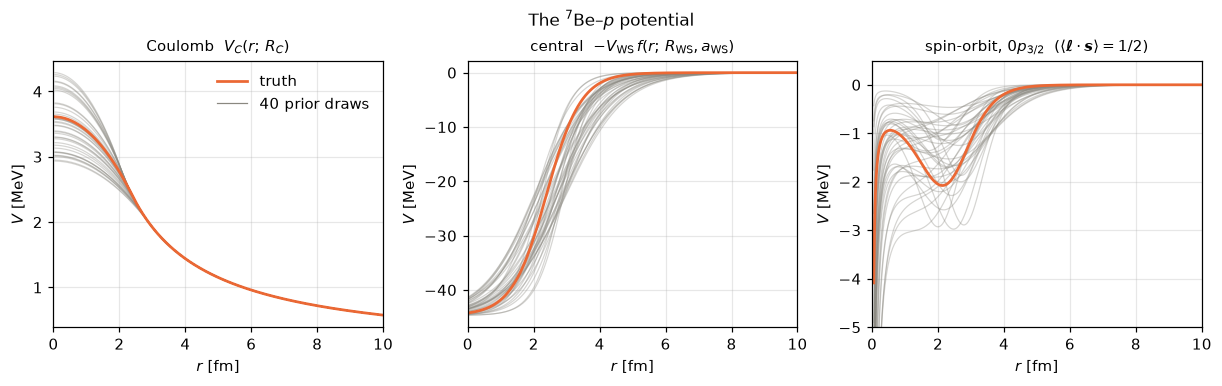

In [22]:
E2 = 1.44  # e^2 [MeV fm]
HBAR_OVER_MPI_C_SQ = 2.0  # (hbar / m_pi c)^2 [fm^2], frescox's spin-orbit constant
Z_CORE, Z_P = 4, 1  # 7Be, p
LS_0P32 = 0.5  # <l.s> = [j(j+1) - l(l+1) - s(s+1)] / 2 for the 0p3/2 proton
V_WS_SEED = 44.675  # MeV; frescox refits this for every sample so that S_p = 137 keV


def woods_saxon(r, R, a):
    return 1.0 / (1.0 + np.exp((r - R) / a))


def potential_terms(r, theta, V_WS=V_WS_SEED):
    """Coulomb, central and spin-orbit (0p3/2) terms of the 7Be-p potential [MeV]."""
    R_C, R_WS, a_WS, V_so = theta
    coulomb = (
        Z_CORE * Z_P * E2 * np.where(r < R_C, (3 - (r / R_C) ** 2) / (2 * R_C), 1 / r)
    )
    f = woods_saxon(r, R_WS, a_WS)
    dfdr = -f * (1 - f) / a_WS
    spin_orbit = 2 * HBAR_OVER_MPI_C_SQ * V_so * dfdr / r * LS_0P32
    return coulomb, -V_WS * f, spin_orbit


TRUTH = np.load("data/mock_data.npz")[
    "theta_truth"
]  # loaded again with the rest of the mock data in Section 3
r = np.linspace(0.05, 10.0, 400)
prior_samples = LO + SPAN * np.random.default_rng(SEED).random(
    (40, 4)
)  # uniform over the prior ranges

fig, ax = plt.subplots(1, 3, figsize=(11, 3.4), constrained_layout=True)
for th in prior_samples:
    for a, term in zip(ax, potential_terms(r, th)):
        a.plot(r, term, color=GREY, lw=0.8, alpha=0.35)
for a, term in zip(ax, potential_terms(r, TRUTH)):
    a.plot(r, term, color=ORANGE, lw=1.8, label="truth")
titles = (
    r"Coulomb  $V_C(r;\,R_C)$",
    r"central  $-V_{\rm WS}\,f(r;\,R_{\rm WS}, a_{\rm WS})$",
    r"spin-orbit, $0p_{3/2}$  ($\langle\boldsymbol{\ell}\cdot\boldsymbol{s}\rangle = 1/2$)",
)
for a, ttl in zip(ax, titles):
    a.set(xlabel="$r$ [fm]", ylabel="$V$ [MeV]", title=ttl, xlim=(0, 10))
    a.title.set_fontsize(10)
ax[2].set_ylim(-5, 0.5) 
ax[0].plot(
    [],
    [],
    color=GREY,
    lw=0.8,
    label=f"{len(prior_samples)} prior draws",
)
ax[0].legend()
fig.suptitle(
    r"The $^{7}$Be–$p$ potential",
    fontsize=11,
)
plt.show()

## 3. The data

Rather than emulating and calibrating the entire 2D, energy and angle dependent, double-differential breakup cross section $d\sigma_{bu}/(d\Omega dE)$, we instead integrate respectively over energy $E$ and solid angle $\Omega$ to isolate the angle and energy dependence in two different observables: 
- $d\sigma_{bu}/d\Omega$ 
- $d\sigma_{bu}/dE$.

These are what would actually be measured in an experiment (breakup measurements on rare isotope beams are typically low statistics, so energy-angle correlations are not typically accessible).

 - `training.npz` holds $\boldsymbol{f}$, all the training data (many points in $(R_C, R_{\rm WS}, a_{\rm WS}, V_{so})$-space)
 - `mock_data.npz` holds, $\boldsymbol{y}_\text{obs}$, the synthetic observations at the one true $(R_C, R_{\rm WS}, a_{\rm WS}, V_{so})$,

both for both of these two observables. 

In [4]:
d = np.load("data/training.npz")
mock = np.load("data/mock_data.npz")

theta, f, x = d["theta"], d["f"], d["x"]
y, yvar = mock["y"], mock["yvar"]
angles, energies = mock["angles_deg"], mock["energies_mev"]
truth_out, TRUTH = mock["truth_output"], mock["theta_truth"]
ANG, ENE = x[:, 0] == 0, x[:, 0] == 1

print(f"theta  {theta.shape}   (samples x parameters)")
print(f"f      {f.shape}   (observables x samples)   <- note the orientation")
print(f"x      {x.shape}   (observables x [kind, coordinate])")
print()
print(
    f"observables: {ANG.sum()} angular (b/sr) + {ENE.sum()} energy (mb/MeV) = {len(x)}"
)
print(f"  angles   {angles.min():.2f} to {angles.max():.2f} deg")
print(f"  energies {energies.min():.3f} to {energies.max():.3f} MeV")
print()
print("truth:", {n: float(v) for n, v in zip(PARAMS, TRUTH)})

theta  (500, 4)   (samples x parameters)
f      (45, 500)   (observables x samples)   <- note the orientation
x      (45, 2)   (observables x [kind, coordinate])

observables: 25 angular (b/sr) + 20 energy (mb/MeV) = 45
  angles   0.00 to 3.00 deg
  energies 0.075 to 2.925 MeV

truth: {'R_C': 2.391, 'R_WS': 2.391, 'a_WS': 0.52, 'V_so': 4.898}


## 4. What the simulator produces

Each design point yields two cross sections: a breakup **angular** distribution $d\sigma/d\Omega$ and a breakup **energy** distribution $d\sigma/dE$. We will plot all those outputs overlaid on top of eachother to get an idea of the dependennce on our four parameters. Notice that the spread is very asymmetric, with a long tail toward large cross sections.

#### Training data selection: 
While resonances are physical features of these few body systems, these sorts of sharp features in output space $d\sigma/dE$ add significant complexity to GP emulation, which is best suited for smooth outputs. Some parameter combinations put a sharp resonance in the $^{7}$Be–$p$ system, creating peaks in $d\sigma/dE$ that are orders of magnitude larger than our synthetic experimental data. Following the paper, training runs with a peak above 1000 mb/MeV are discarded: such outputs have essentially zero posterior density and only make the emulator's job harder.

kept 399 of 500 runs (20.2% cut; the paper cuts 21.4%)


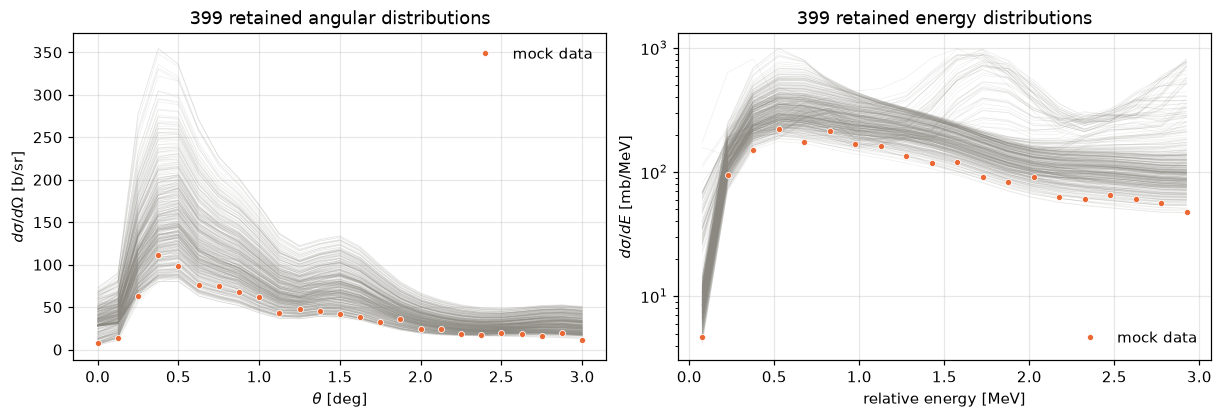

In [5]:
keep = ~np.isnan(f).any(axis=0) & (np.nanmax(f[ENE], axis=0) <= 1000.0)
print(
    f"kept {keep.sum()} of {len(keep)} runs "
)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.7), constrained_layout=True)
for a, m, xs, xl, yl, ttl in (
    (ax[0], ANG, angles, r"$\theta$ [deg]", r"$d\sigma/d\Omega$ [b/sr]", "angular"),
    (ax[1], ENE, energies, "relative energy [MeV]", r"$d\sigma/dE$ [mb/MeV]", "energy"),
):
    a.plot(xs, f[np.ix_(m, keep)], color=GREY, lw=0.4, alpha=0.15)
    a.plot(
        xs,
        y[m],
        "o",
        ms=4,
        color=ORANGE,
        mec="white",
        mew=0.5,
        ls="none",
        label="mock data",
        zorder=5,
    )
    a.set(xlabel=xl, ylabel=yl, title=f"{int(keep.sum())} retained {ttl} distributions")
    a.legend()
ax[1].set_yscale("log")
plt.show()

## 5. Fitting the emulator

`PCGPwM` standardizes each observable, reduces the output with PCA, and fits an independent GP to each principal component. See Appendix B of the paper for details. 

We fit it to $\log\sigma$ rather than $\sigma$ because cross sections are strictly positive.

In [6]:
theta_k, f_k = theta[keep], f[:, keep]

rng = np.random.default_rng(SEED)
order = rng.permutation(len(theta_k))
n_test = int(round(0.25 * len(theta_k)))
test, train = np.sort(order[:n_test]), np.sort(order[n_test:])
print(f"train {len(train)}, test {len(test)}")


def fit(rows):
    """Fit PCGPwM to log(sigma) on the training split."""
    np.random.seed(SEED)  # surmise subsamples internally
    return emulator(
        x=x[rows],
        theta=theta_k[train],
        f=np.log(f_k[rows][:, train]),
        method="PCGPwM",
        args={"warnings": False},
    )


def predict(emu, rows, th):
    """Predictive mean, back in linear units (b/sr, mb/MeV)."""
    return np.exp(emu.predict(x=x[rows], theta=np.atleast_2d(th)).mean())


ALL = np.ones(len(x), bool)
emus = {"angular": fit(ANG), "energy": fit(ENE), "combined": fit(ALL)}
print("fitted:", ", ".join(emus))

train 299, test 100
fitted: angular, energy, combined


## 6. Validating the emulator

We use the following metrics:

- **Held-out accuracy** — predict the 25% of design points the GP never saw
- **Accuracy at the truth** — the single point the calibration actually has to get right.

In [7]:
def r2_of(emu, rows):
    pred, true = predict(emu, rows, theta_k[test]), f_k[rows][:, test]
    return 1 - np.sum((pred - true) ** 2) / np.sum(
        (true - true.mean(1, keepdims=True)) ** 2
    )


print(
    f"{'observable':>10} {'d':>4} {'test r2':>9} {'median |rel err|':>17} "
    f"{'at truth':>10}"
)
for name, rows in (("angular", ANG), ("energy", ENE), ("combined", ALL)):
    emu = emus[name]
    pred, true = predict(emu, rows, theta_k[test]), f_k[rows][:, test]
    at_truth = predict(emu, rows, TRUTH).ravel()
    tv = truth_out[rows]
    print(
        f"{name:>10} {int(rows.sum()):4d} {r2_of(emu, rows):9.4f} "
        f"{np.median(np.abs(pred - true) / true):17.4f} "
        f"{np.median(np.abs(at_truth - tv) / tv):10.4f} "
    )

observable    d   test r2  median |rel err|   at truth
   angular   25    0.9942            0.0067     0.1276 
    energy   20    0.9340            0.0152     0.2540 
  combined   45    0.9432            0.0125     0.1600 


Note that the relative error in the emulator at the truth is much larger than it is over the whole prior - this is because our truth sits at an extreme edge in output space with respect to our prior predictive. In practice, at this point one might want to recognize this, and alter the training design to better envelop the data we are trying to fit. We'll keep running with this design and see how we do. 

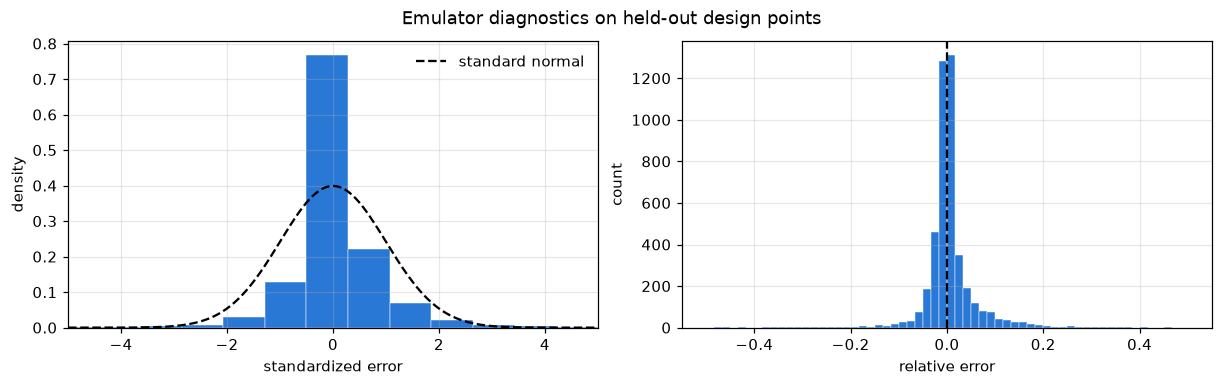

In [8]:
emu = emus["combined"]
p = emu.predict(x=x, theta=theta_k[test])
mean_lin = np.exp(p.mean())
var_lin = mean_lin**2 * p.var()  # delta method, log -> linear
true = f_k[:, test]
std_err = ((mean_lin - true) / np.sqrt(var_lin)).ravel()
rel_err = ((mean_lin - true) / true).ravel()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4), constrained_layout=True)
ax[0].hist(std_err, bins=60, density=True, color=BLUE, edgecolor="white", lw=0.3)
g = np.linspace(-5, 5, 300)
ax[0].plot(
    g,
    np.exp(-(g**2) / 2) / np.sqrt(2 * np.pi),
    color="black",
    lw=1.5,
    ls="--",
    label="standard normal",
)
ax[0].set(xlabel="standardized error", ylabel="density", xlim=(-5, 5))
ax[0].legend()
ax[1].hist(rel_err, bins=60, color=BLUE, edgecolor="white", lw=0.3, range=(-0.5, 0.5))
ax[1].axvline(0, color="black", lw=1.5, ls="--")
ax[1].set(xlabel="relative error", ylabel="count")
fig.suptitle("Emulator diagnostics on held-out design points")
plt.show()

## 7. Calibration

Our emulator is satisfacorally fit. Now the Bayesian step. Here we take the same prior as the paper: a Beta(3.5, 3.5) distribution rescaled onto each parameter range. This gives a prior that is concentrated toward the middle and vanishing at the edges. The posterior is sampled with parallel-tempered Langevin Monte Carlo (`PTLMC`).

Because the emulator lives in log space, the observations are transformed to match: a 10% relative error is a constant additive 0.1 in log units.

In [9]:
class Prior:
    """Beta(3.5, 3.5) on each parameter, rescaled to its range."""

    def lpdf(t):  # noqa: N805 - surmise calls it unbound
        t = np.atleast_2d(t)
        total = sum(
            sps.beta.logpdf((t[:, i] - LO[i]) / SPAN[i], 3.5, 3.5) - np.log(SPAN[i])
            for i in range(4)
        )
        return total.reshape(len(t), 1)  # the (n, 1) shape is required

    def rnd(n):  # noqa: N805
        return sps.beta.rvs(3.5, 3.5, size=(n, 4)) * SPAN + LO


np.random.seed(SEED)

In [10]:
# conservative choice here
# 10% relative 'experimental' error + 25% GP error (maximum error at truth)
REL_ERR = 0.1 + 0.25 
yvar = (np.full(y.size, REL_ERR**2),)  # constant relative error is additive in log

In [11]:
%%time
cal = calibrator(
    emu=emus["combined"],
    y=np.log(y),  # emulator is in log space
    x=x,
    thetaprior=Prior,
    method="directbayeswoodbury",
    yvar=yvar,
    args={"sampler": "PTLMC", "maxtemp": 30},
)

CPU times: user 2min 29s, sys: 336 ms, total: 2min 29s
Wall time: 53.5 s


## 8. The posterior

In [12]:
draws = cal.theta.rnd(5000)
print(f"posterior draws: {draws.shape}")

posterior draws: (5000, 4)


In [13]:
print(
    f"  {'param':6s} {'mean':>8} {'sd':>8} {'2.5%':>8} {'97.5%':>8} {'truth':>8}"
    f" {'sd/prior':>9}  covers truth?"
)
for i, name in enumerate(PARAMS):
    c = draws[:, i]
    lo, hi = np.percentile(c, [2.5, 97.5])
    print(
        f"  {name:6s} {c.mean():8.4f} {c.std():8.4f} {lo:8.4f} {hi:8.4f} "
        f"{TRUTH[i]:8.4f} {c.std() / SPAN[i]:9.3f}  "
        f"{'yes' if lo <= TRUTH[i] <= hi else 'NO'}"
    )
print(
    "\nBeta(3.5, 3.5) has sd/range = 0.177, so smaller means the data were informative"
)

  param      mean       sd     2.5%    97.5%    truth  sd/prior  covers truth?
  R_C      2.4629   0.1705   2.1649   2.8284   2.3910     0.171  yes
  R_WS     2.3886   0.0455   2.3159   2.4639   2.3910     0.046  yes
  a_WS     0.5263   0.0429   0.4454   0.6135   0.5200     0.086  yes
  V_so     5.1850   1.1305   2.9901   7.1506   4.8980     0.188  yes

Beta(3.5, 3.5) has sd/range = 0.177, so smaller means the data were informative


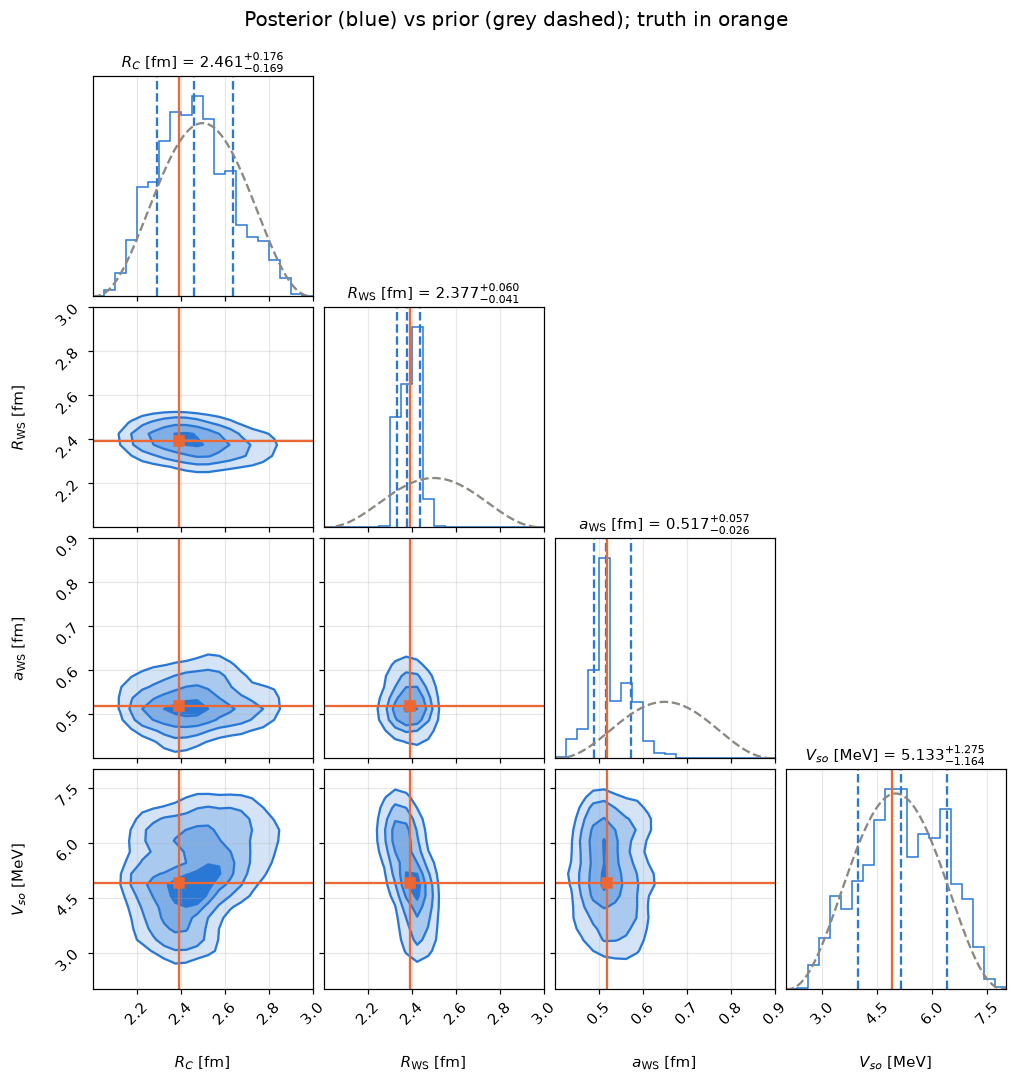

In [14]:
fig = corner.corner(
    draws,
    labels=list(LABELS),
    truths=list(TRUTH),
    truth_color=ORANGE,
    color=BLUE,
    range=[tuple(r) for r in RANGES],  # show the full prior support
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".3f",
    title_kwargs={"fontsize": 10},
    hist_kwargs={"density": True},
    plot_datapoints=False,
    fill_contours=True,
    smooth=1.0,
)
# overlay the prior on each diagonal, so "informative" is visible rather than asserted
prior_draws = Prior.rnd(20000)
axes = np.array(fig.axes).reshape(4, 4)
for i in range(4):
    ax = axes[i, i]
    grid = np.linspace(*RANGES[i], 200)
    dens = sps.beta.pdf((grid - LO[i]) / SPAN[i], 3.5, 3.5) / SPAN[i]
    ax.plot(grid, dens, color=GREY, lw=1.5, ls="--")
fig.suptitle(
    "Posterior (blue) vs prior (grey dashed); truth in orange", y=1.02, fontsize=13
)
plt.show()

The headline result: **$R_{\rm WS}$ and $a_{\rm WS}$ are
sharply determined by breakup data, while $R_C$ and $V_{so}$ are barely informed at all** —
their marginals sit almost on top of the prior. 

## 9. The ANC of the $^{8}$B ground state

The **asymptotic normalization coefficient** (ANC) is a quantity of direct physical interest that the posterior of our $^{7}$Be–$p$ interaction determines. 
Far outside the $^{7}$Be core the bound $0p_{3/2}$ proton wave function has a universal shape; a Whittaker function. 
There, only its overall size depends on the interaction:

$$u(r) \;\xrightarrow{\;r \to \infty\;}\; C \, W_{-\eta,\,l+1/2}(2\kappa r), \qquad
C \equiv \text{ANC}.$$

$C^2$ fixes the low-energy $^{7}$Be$(p,\gamma)^{8}$B capture rate that matters for the solar-neutrino flux, so this is the number the breakup experiment is ultimately after.

The ANC is a property of the **two-body** $^{7}$Be–$p$ bound state alone, no dependence on the target: we get to use a simplified two-body frescox input that runs quickly, no emulation needed. 
`model/anc.template` is the `bfrescox` template file we will use for this bound-state problem. 
Frescox will, for each $(R_C, R_{\rm WS}, a_{\rm WS}, V_{so})$, rescale the central depth to give us the 137 keV separation energy (`isc=1`), solve for the the bound state, and write $u(R)/W(R)$ as a function of $R$ to its `fort.46` output file. Beyond ~10 fm, outside the range of the interaction -- as we will see -- that ratio asymptotes to the ANC.

In [15]:
TEMPLATE = "model/anc.template"
with open(TEMPLATE) as fptr:
    lines = fptr.read().splitlines()
print(
    "\n".join(
        l for l in lines if "@" in l or "kp= 4" in l or "Overlap" in l or "kbpot" in l
    )
)

 &Pot kp= 4 type= 0 shape= 0
      p(1:3)=    1.0000   0.0000   @rC_p_7Be@ /
 &Pot kp= 4 type= 1 shape= 0
      p(1:3)=   @V_p_7Be@   @rV_p_7Be@   @aV_p_7Be@ /
 &Pot kp= 4 type= 3 shape= 0
      p(1:3)=    @Vso_p_7Be@   @rso_p_7Be@   @aso_p_7Be@ /
 &Overlap kn1=  1 kn2=  0 ic1=1 ic2=2 in= 1
    kbpot= 4 be=  0.1370 isc= 1 ipc=1 /
 &Overlap /   ! END OF DEFINING OVERLAPS


### Run `Bfrescox` once at the true parameters, to get the true ANC

In [16]:
import os, tempfile
import bfrescox


def potential_parameters(theta):
    """The seven @placeholders@ of anc.template, from (R_C, R_WS, a_WS, V_so)."""
    R_C, R_WS, a_WS, V_so = theta
    return {
        "rC_p_7Be": R_C,  # Coulomb radius
        "V_p_7Be": 44.675,  # central depth: a seed, isc=1 refits it
        "rV_p_7Be": R_WS,
        "aV_p_7Be": a_WS,  # central Woods-Saxon geometry
        "Vso_p_7Be": V_so,
        "rso_p_7Be": R_WS,
        "aso_p_7Be": a_WS,
    }  # spin-orbit: same geometry


wd = tempfile.mkdtemp()  # frescox writes fort.* into its cwd

# write the frescox inpuit from the template, using the ground truth parameters
cfg = bfrescox.Configuration.from_template(
    TEMPLATE, f"{wd}/anc.in", potential_parameters(TRUTH), overwrite=True
)

# run frescox
bfrescox.run_simulation(cfg, f"{wd}/frescox.out", overwrite=True, cwd=wd)

# read the fort.46 file to extreact the overlap
R, anc_R, u, W = np.loadtxt(f"{wd}/fort.46", comments=("#", "&")).T

# take the last (largest r) value
anc_truth = anc_R[-1]
print(
    f"ANC at the truth: {anc_truth:.4f} fm^-1/2   (Capel & Nunes 2006, same potential: 0.7008)"
)

ANC at the truth: 0.7008 fm^-1/2   (Capel & Nunes 2006, same potential: 0.7008)


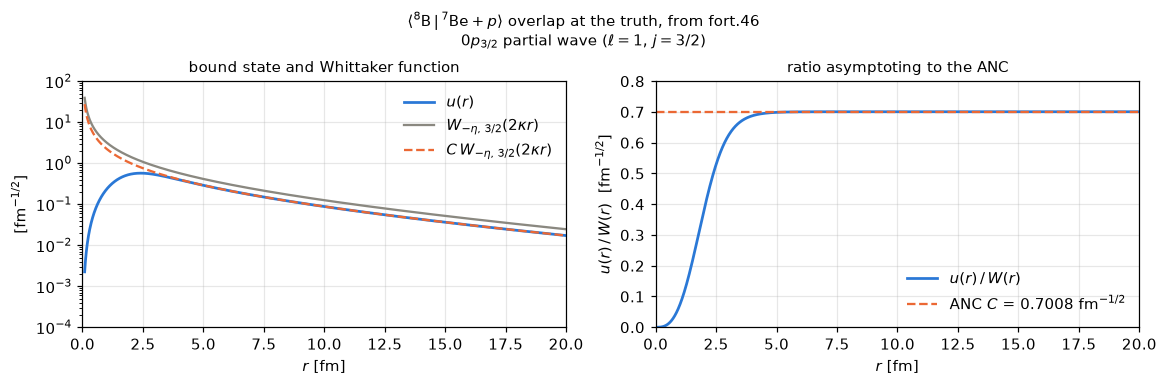

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.4), constrained_layout=True)
ax[0].plot(R, u, color=BLUE, lw=1.8, label=r"$u(r)$")
ax[0].plot(R, W, color=GREY, lw=1.5, label=r"$W_{-\eta,\,3/2}(2\kappa r)$")
ax[0].plot(
    R,
    anc_truth * W,
    color=ORANGE,
    lw=1.5,
    ls="--",
    label=r"$C\,W_{-\eta,\,3/2}(2\kappa r)$",
)
ax[0].set(
    xlabel="$r$ [fm]",
    ylabel=r"[fm$^{-1/2}$]",
    xlim=(0, 20),
    ylim=(1e-4, 1e2),
    yscale="log",
    title="bound state and Whittaker function",
)
ax[0].legend()
ax[1].plot(R, anc_R, color=BLUE, lw=1.8, label=r"$u(r)\,/\,W(r)$")
ax[1].axhline(
    anc_truth,
    color=ORANGE,
    ls="--",
    lw=1.5,
    label=f"ANC $C$ = {anc_truth:.4f} fm$^{{-1/2}}$",
)
ax[1].set(
    xlabel="$r$ [fm]",
    ylabel=r"$u(r)\,/\,W(r)$  [fm$^{-1/2}$]",
    xlim=(0, 20),
    ylim=(0, 0.8),
    title="ratio asymptoting to the ANC",
)
ax[1].legend(loc="lower right")
for a in ax:
    a.title.set_fontsize(10)
fig.suptitle(
    r"$\langle {}^{8}\mathrm{B} \,|\, {}^{7}\mathrm{Be} + p \rangle$ overlap at the truth, from fort.46" + "\n"
    r"$0p_{3/2}$ partial wave ($\ell = 1$, $j = 3/2$)",
    fontsize=10,
)
plt.show()

Each two-body calculation takes a fraction of a second on serial frescox.  We will use `bfrescox` to drive these calculations directly from the notebook.  Unlike the breakup cross sections, there is no emulator needed!

### Run `Bfrescox` for prior and posterior samples, to see how well we inferred the ANC from breakup

In [18]:
%%time
from concurrent.futures import ThreadPoolExecutor


def anc(theta):
    """ANC of the 8B ground state at theta: fill the template, run frescox, read fort.46."""
    with tempfile.TemporaryDirectory() as wd:
        cfg = bfrescox.Configuration.from_template(
            TEMPLATE, f"{wd}/anc.in", potential_parameters(theta), overwrite=True
        )
        bfrescox.run_simulation(cfg, f"{wd}/frescox.out", overwrite=True, cwd=wd)
        # grab the last row of the column containing u/W ratio
        return np.loadtxt(f"{wd}/fort.46", comments=("#", "&"))[-1, 1]


def anc_for_samples(thetas, n_workers=min(8, os.cpu_count())):
    # frescox is a separate process per call, so threads are enough to run several at once
    with ThreadPoolExecutor(n_workers) as pool:
        return np.array(list(pool.map(anc, thetas)))


anc_prior = anc_for_samples(theta)  # the 500 design points
post = draws[np.random.default_rng(SEED).choice(len(draws), 1000, replace=False)]
anc_post = anc_for_samples(post)  # 1000 posterior draws

C, C2 = anc_post, anc_post**2
print(f"posterior ANC  C  = {C.mean():.3f} ± {C.std():.3f} fm^-1/2")
print(
    f"posterior      C² = {C2.mean():.3f} ± {C2.std():.3f} fm^-1     (paper: 0.49 ± 0.01)"
)

posterior ANC  C  = 0.703 ± 0.020 fm^-1/2
posterior      C² = 0.495 ± 0.029 fm^-1     (paper: 0.49 ± 0.01)
CPU times: user 8.63 s, sys: 2.1 s, total: 10.7 s
Wall time: 48.9 s


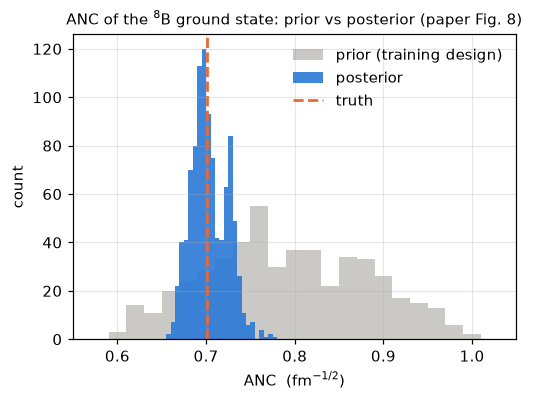

In [19]:
fig, ax = plt.subplots(figsize=(5.2, 3.6))
ax.hist(
    anc_prior[np.isfinite(anc_prior)],
    bins=np.linspace(0.55, 1.05, 26),
    color=GREY,
    alpha=0.45,
    label="prior (training design)",
)
ax.hist(
    anc_post[np.isfinite(anc_post)],
    bins=np.arange(0.55, 1.05, 0.005),
    color=BLUE,
    alpha=0.9,
    label="posterior",
)
ax.axvline(anc_truth, color=ORANGE, ls="--", lw=1.8, label="truth")
ax.set_xlabel(r"ANC  (fm$^{-1/2}$)")
ax.set_ylabel("count")
ax.set_xlim(0.55, 1.05)
ax.legend(loc="upper right")
ax.set_title("ANC of the $^{8}$B ground state")
plt.show()

## 10. Posterior predictive

Pushing the posterior back through the emulator gives credible intervals on the breakup cross sections themselves. 
A calibrated model should reproduce the data it was fitted to, with intervals that are neither too narrow nor too wide.

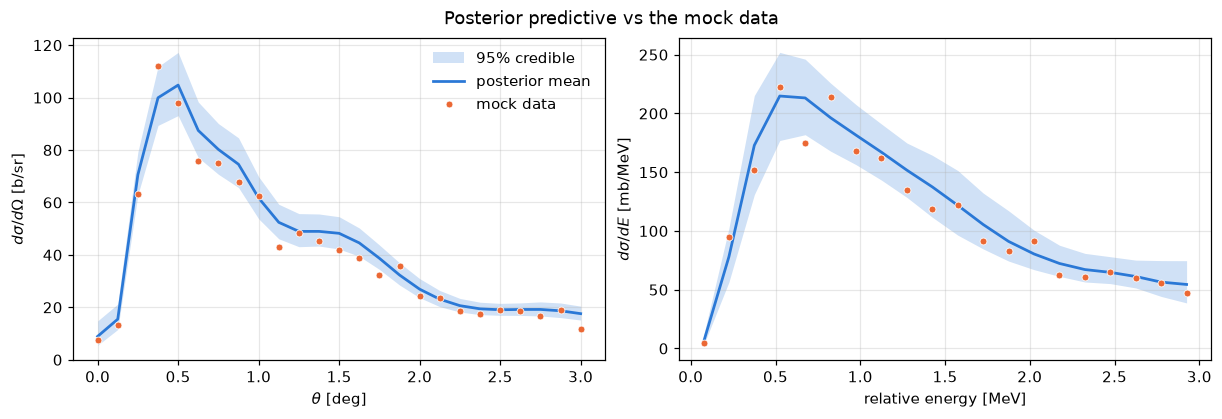

In [20]:
pred_obj = cal.predict(x)
pred_log = pred_obj.rnd(s=2000)  # needed before empirical_coverage()
pred = np.exp(pred_log)  # back to b/sr and mb/MeV

lo, hi = np.percentile(pred, [2.5, 97.5], axis=0)
mu = pred.mean(axis=0)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.7), constrained_layout=True)
for a, m, xs, xl, yl in (
    (ax[0], ANG, angles, r"$\theta$ [deg]", r"$d\sigma/d\Omega$ [b/sr]"),
    (ax[1], ENE, energies, "relative energy [MeV]", r"$d\sigma/dE$ [mb/MeV]"),
):
    a.fill_between(xs, lo[m], hi[m], color=BLUE, alpha=0.22, lw=0, label="95% credible")
    a.plot(xs, mu[m], color=BLUE, lw=1.8, label="posterior mean")
    a.plot(
        xs,
        y[m],
        "o",
        ms=4.5,
        color=ORANGE,
        mec="white",
        mew=0.5,
        ls="none",
        label="mock data",
    )
    a.set(xlabel=xl, ylabel=yl)
ax[0].legend()
fig.suptitle("Posterior predictive vs the mock data")
plt.show()

## 11. Empirical coverage

If the posterior uncertainty is honest, a nominal $p$% interval
should contain the observation about $p$% of the time.

There are **two different intervals**:

- a **credible interval for the model prediction** — where the calibrated simulator says
  the true cross section lies;
- a **predictive interval for a new observation** — the same, *plus* the 10% measurement
  noise the data carry.

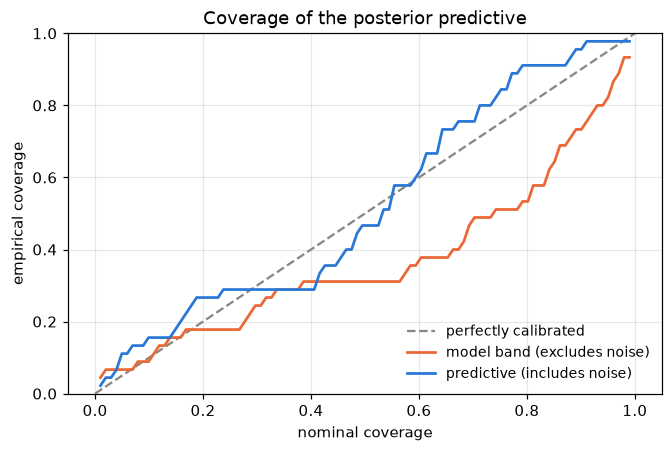

In [21]:
levels = np.linspace(0.01, 0.99, 100)

pred_obj.empirical_coverage(levels)
_, cov_model = pred_obj.info["coverage"]
cov_model = np.atleast_1d(cov_model)

# Add the measurement noise to get a predictive interval for a new observation.
# A 10% relative error is additive N(0, 0.1^2) in log space.
noise = np.random.default_rng(1).normal(0.0, 0.1, size=pred_log.shape)
pred_obs = np.exp(pred_log + noise)


def coverage(sample):
    return np.array(
        [
            (
                (y >= np.percentile(sample, 100 * (1 - L) / 2, axis=0))
                & (y <= np.percentile(sample, 100 * (1 + L) / 2, axis=0))
            ).mean()
            for L in levels
        ]
    )


cov_obs = coverage(pred_obs)
fig, ax = plt.subplots(figsize=(6.0, 4.0), constrained_layout=True)
ax.plot([0.0, 1], [0.0, 1], color=GREY, ls="--", lw=1.5, label="perfectly calibrated")
ax.plot(
    levels, cov_model, color=ORANGE, ms=8, lw=1.8, label="model band (excludes noise)"
)
ax.plot(levels, cov_obs, color=BLUE, ms=8, lw=1.8, label="predictive (includes noise)")
ax.set(
    xlabel="nominal coverage",
    ylabel="empirical coverage",
    title="Coverage of the posterior predictive",
)
ax.legend(loc="lower right", fontsize=9)
ax.set_ylim([0, 1])
plt.show()

## Congratulations! 

You have successfully produced a calibrated, uncertainty quantified model of the ${}^{7}\mathrm{Be} \leftrightarrow p$ interaction from breakup cross sections, and used it to infer the ANC of the halo proton in the exotic $^8\rm{B}$ nucleus. Running full CDCC calculations at each parameter sample would take about 65 cpu-hours per sample. Using surmise and GP emulation, we have done it in minutes! Of course, generating the training data, which I did for you, did take ~32K cpu-hours, but it only required 500 training points. Plugging CDCC into a MCMC sampler directly would probably require a few orders of magnitude more samples, which would be infeasible. Together, `Bfrescox` and `surmise` make this difficult inference problem possible. Exciting times we live in, eh?

>  Kyle Beyer

### Addendum: Regenerating the training data with `Bfrescox`

`data/training.npz` came from 500 CDCC runs at ~65 core-hours each. To reproduce it:

```bash
pip install -r requirements.txt -r requirements-model.txt   # needs a Fortran compiler + MPI
python model/run_design_point.py --index 0 --ranks 32       # one point, ~2 h on 32 ranks
python model/run_design_point.py --assemble                 # samples/ -> data/training.npz
```

In practice this is a SLURM array over `--index 0..499`. See `model/run_design_point.py` and the `README.md`. If you have an idle cluster, feel free to try to regenerate the training data, or, better yet, adapt this example to your own interesting breakup problem!